# 04: Shapley (SHAP) -iris classifier

While global feature importances tel us which features were useful on avaerage accross the entire dataset, they do not explain *why* the model made a specific decision for a *single* flower.To solve this, we use **Shapley Addictive exPlanations (SHAP)**.

### Shapley Values
The SHAP value represents the fair contribution of each physical measurement to the final prediction, shifting it away from the baseline avaerage prediction. 
* A **positive** SHAP value means that feature pushed the model to predict "Yes" (1).
* A **negative** SHAP value means that feature pushed the model to predict "No" (0).

### AIM
* To implement local interpretability using SHAP.
* To compute, aggregate and plot Shapley values on both our training and testing data splits. 

### METHOD
* Train an XGBoost Classifier using NumPy arrays.
* Initiate a shap.TreeExplainer optimised for tree-based models on training set.
* Extract the 2D array of SHAP values. Since XGBoost classification outputs direct 2D arrays, no slicing is needed.
* Calculate the mean absolute SHAP value for each feature to generate a feature importance chart.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.utils_classifier
# Import machine learning methods
from xgboost import XGBClassifier, plot_tree 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
#unable to import shap for shapley values

In [2]:
from sklearn import datasets
iris=datasets.load_iris()

In [3]:
df = pd.DataFrame(iris["data"], columns=iris['feature_names'])
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
feature_names=list(iris["feature_names"])
species_names=list(iris["target_names"])
print(feature_names,species_names)

df_ohe_species = pd.get_dummies(df['species']).astype(int)
df = pd.concat((df, df_ohe_species), axis='columns')
df.head()

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


In [5]:
species="versicolor"
X_df = df[feature_names]
y_df = df[species]
X = X_df.values
y = y_df.values

In [6]:
dict_accuracy={}
dict_featureimp={}

for species in (species_names):

    X_df = df[feature_names]
    y_df = df[species]

    X = X_df.values
    y = y_df.values

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25)
    
    model = XGBClassifier(random_state=42, verbosity=0)
    model.fit(X_train, y_train)

    # Predict training and test set labels
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Predict probabilities of survival
    y_prob_train = model.predict_proba(X_train)
    y_prob_test = model.predict_proba(X_test)

    #calculate accuracy
    accuracy_train = np.mean(y_pred_train == y_train)
    accuracy_test = np.mean(y_pred_test == y_test)

    print (f'Accuracy of predicting training data for {species}= {accuracy_train:0.3f}')
    
    print (f'Accuracy of predicting test data for {species} = {accuracy_test:0.3f}')

Accuracy of predicting training data for setosa= 1.000
Accuracy of predicting test data for setosa = 1.000
Accuracy of predicting training data for versicolor= 1.000
Accuracy of predicting test data for versicolor = 1.000
Accuracy of predicting training data for virginica= 0.991
Accuracy of predicting test data for virginica = 1.000


In [7]:
feature_importances = model.feature_importances_
importances = pd.DataFrame(index=feature_names)
importances['importance'] = feature_importances
importances['rank'] = importances['importance'].rank(ascending=False).values
importances.sort_values('rank').head()

,importance,rank
petal length (cm),0.698212,1.0
petal width (cm),0.264378,2.0
sepal width (cm),0.028051,3.0
sepal length (cm),0.009358,4.0


In [9]:
# Train explainer on Training set
explainer = shap.TreeExplainer(model)
    
# Get Shap values (extended version has other data returned as well as shap values)
shapley_values_train_extended = explainer(X_train)
shapley_values_train = shapley_values_train_extended.values
shapley_values_test_extended = explainer(X_test)
shapley_values_test = shapley_values_test_extended.values

# Calculate mean Shapley value for each feature in trainign set
importances['mean_shapley_values'] = np.mean(shapley_values_train, axis=0)

# Calculate mean absolute Shapley value for each feature in trainign set
# This will give us the average importance of each feature
importances['mean_abs_shapley_values'] = np.mean(
    np.abs(shapley_values_train),axis=0)

In [10]:
importances.sort_values(by='importance', ascending=False).head()
importances.head(10)

,importance,rank,mean_shapley_values,mean_abs_shapley_values
sepal length (cm),0.009358,4.0,-0.071617,0.289545
sepal width (cm),0.028051,3.0,-0.401609,1.044829
petal length (cm),0.698212,1.0,-0.427232,2.567466
petal width (cm),0.264378,2.0,-0.723302,2.387358


In [11]:
# Get top 10 features
importance_top_10 = \
    importances.sort_values(by='importance', ascending=False).head(10).index
shapley_top_10 = \
    importances.sort_values(
    by='mean_abs_shapley_values', ascending=False).head(10).index

# Add to DataFrame
top_10_features = pd.DataFrame()
top_10_features['importances'] = importance_top_10.values
top_10_features['Shapley'] = shapley_top_10.values

# Display
top_10_features

,importances,Shapley
0,petal length (cm),petal length (cm)
1,petal width (cm),petal width (cm)
2,sepal width (cm),sepal width (cm)
3,sepal length (cm),sepal length (cm)


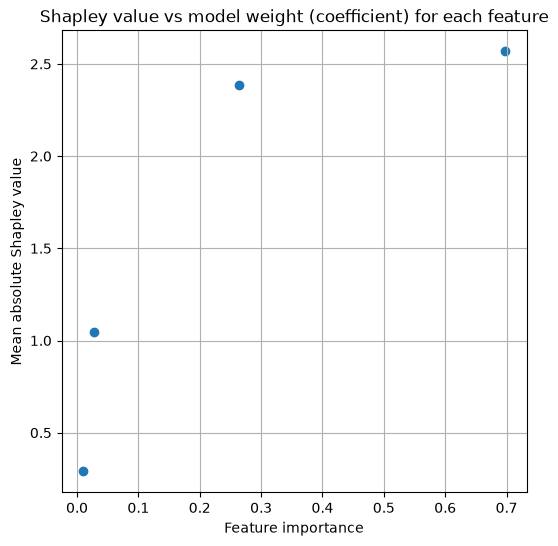

In [12]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
# Plot points
x = importances['importance']
y = importances['mean_abs_shapley_values']
ax.scatter(x, y)
ax.set_title('Shapley value vs model weight (coefficient) for each feature')
ax.set_ylabel('Mean absolute Shapley value')
ax.set_xlabel('Feature importance')
plt.grid()
plt.show()

Summary Plot

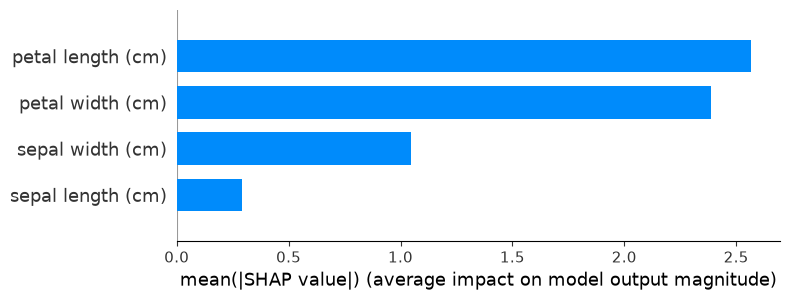

In [20]:
fig = plt.figure(figsize=(6,6))

shap.summary_plot(shap_values = shapley_values_train, 
                  features = X_train,
                  feature_names=feature_names,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.tight_layout()
plt.show()

Beeswarm Plot

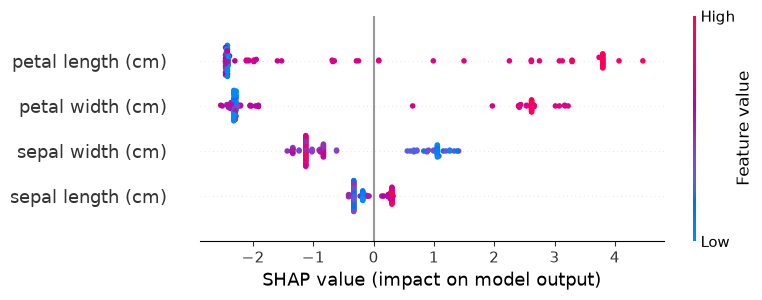

In [23]:
fig = plt.figure(figsize=(6,6))

shap.summary_plot(shap_values = shapley_values_train, 
                  features = X_train,
                  feature_names=feature_names,
                  max_display=15,
                  show=False)
plt.tight_layout()
plt.show()

Waterfall Plot

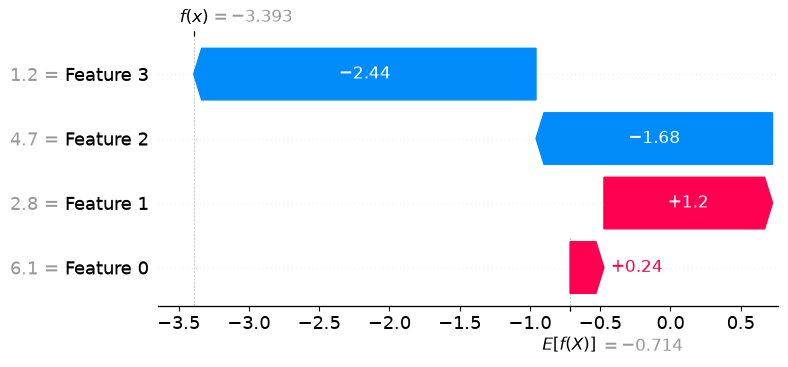

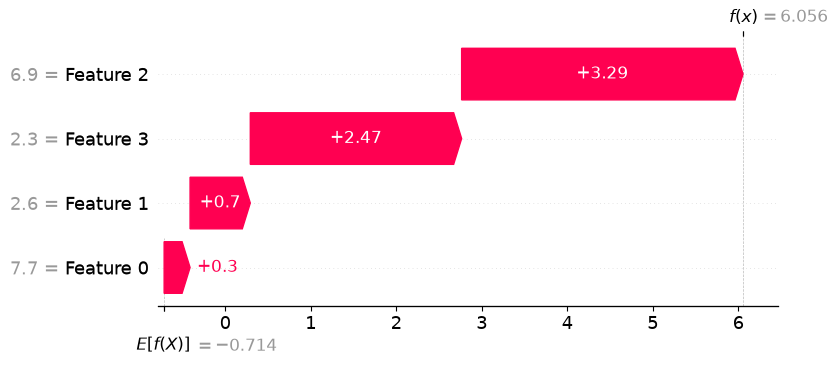

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

# Get the location of an example each where probability is <0.01 or >0.99

location_low_probability = np.where(y_prob < 0.05)[0][0]
location_high_probability = np.where(y_prob > 0.95)[0][0]

#lowest probability plot (least likely to be predicted as species)
shap.plots.waterfall(shapley_values_test_extended[location_low_probability], 
                     max_display=15)

#highest probability plot (most likely to be predicted as species)
shap.plots.waterfall(shapley_values_test_extended[location_high_probability], 
                     max_display=15)